<a href="https://colab.research.google.com/github/busybey11/clinical-data-portfolio/blob/main/Project_2_Quality_Control_Lab_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2: Quality Control - Lab Data

**Short description:** Laboratory Data QC
Portfolio Project 2 in Clinical Data Analysis Using Python

**Author:** Beah V. Vega

**Study:** CRO2026-LDM-201

**Date:** 2026-06-30

**Introduction**

In a CRO setting, a central laboratory transmits a raw lab data transfer file to the sponsor
on a regular schedule. Before data can be standardized into SDTM or used for safety review,
it must pass through Laboratory Data Management (LDM) QC.

This notebook simulates that workflow on a synthetic raw transfer file, demonstrating:
- Format and structural validation
- Unit standardization (SI → US conventional)
- Out-of-range result flagging
- Missing result detection
- Duplicate/conflicting resubmission detection


**Importance of each QC check**

| Check | LDM rationale |
|---|---|
| Unit standardization | Mixed units make cross-site safety comparison meaningless |
| Out-of-range flagging | Drives queries to sites and medical monitor review |
| Missing result/no reason | Protocol violation; blocks sponsor transmission until resolved |
| Duplicate detection | Conflicting resubmissions must be reconciled before sponsor data lock |
| Format standardization | Inconsistent dates/IDs break automated downstream SDTM mapping |

**Outputs to be produced:**
1. `cleaned_lab_data.csv` - standardized dataset with QC flags
2. `discrepancy_log.csv` - auditable log of every finding (with stub query text)
3. `qc_summary_charts.png` - visual summary for reporting


**Instructions:**
1. Upload raw_lab_transfer_20260301.csv to Files tab in the left side bar of the Colab notebook or mount Google Drive to access the sample lab transfer csv file.
2. Create a new cell containing code blocks.
3. Run cells in order from top to bottom. It is also important to read comments (lines with #) before running each code block.
4. Read text cells to better understand what each code block does.


> **Note on the dataset:** `raw_lab_transfer_20260301.csv` is a synthetic file built to
> simulate the messy, pre-standardization data an LDM team actually receives from a
> central lab. Public CDISC/SDTM datasets are already clean and would not contain these
> realistic QC issues.

**Upload raw lab transfer file or mount Google Drive**

Upload raw lab transfer file manually or run the code below to mount Google Drive and find the file directory for the raw lab transfer file.

In [6]:
# NOTE: Do not run this if you choose to upload the raw lab transfer file manually.

from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

print("\nGoogle Drive mounted successfully.")

# Define the path to access author's Google Drive
drive_path = '/content/drive/MyDrive'

# Path to Colab_Notebooks
colab_notebooks_path = os.path.join(drive_path, 'Colab_Notebooks')

# Check if the 'Colab_Notebooks' path exists and list its contents
if os.path.exists(colab_notebooks_path):
    print(f"\nContents of {colab_notebooks_path}:")
    for item in os.listdir(colab_notebooks_path):
        print(f"- {item}")

    # Path to Clinical Data Sample Projects inside Colab_Notebooks
    clinical_data_path = os.path.join(colab_notebooks_path, 'Clinical Data Sample Projects')

    # Check if the 'Clinical Data Sample Projects' path exists and list its contents
    if os.path.exists(clinical_data_path):
        print(f"\nContents of {clinical_data_path}:")
        for item in os.listdir(clinical_data_path):
            print(f"- {item}")

        # Path to Project_2_Raw_files inside Clinical Data Sample Projects
        project_2_raw_files_path = os.path.join(clinical_data_path, 'Project_2_Raw_files')

        # Check if the 'Project_2_Raw_files' path exists and list its contents
        if os.path.exists(project_2_raw_files_path):
            print(f"\nContents of {project_2_raw_files_path}:")
            for item in os.listdir(project_2_raw_files_path):
                print(f"- {item}")
        else:
            print(f"Error: {project_2_raw_files_path} does not exist. Please verify the folder name and path.")

    else:
        print(f"Error: {clinical_data_path} does not exist. Please verify the folder name and path.")

elif os.path.exists(drive_path):
    print(f"Error: {colab_notebooks_path} does not exist. Please verify the folder name and path.")
else:
    print(f"Error: {drive_path} does not exist after mounting. Please check if Google Drive mounted correctly.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Google Drive mounted successfully.

Contents of /content/drive/MyDrive/Colab_Notebooks:
- Metagenomic Analysis of Gut Microbiota - Ulcerative Colitis
- Clinical Data Sample Projects

Contents of /content/drive/MyDrive/Colab_Notebooks/Clinical Data Sample Projects:
- Project 2: Quality Control - Lab Data 
- Project 1: Quality Control - Clinical Data .ipynb
- Project_2_Raw_files

Contents of /content/drive/MyDrive/Colab_Notebooks/Clinical Data Sample Projects/Project_2_Raw_files:
- raw_lab_transfer_20260301.csv


**Setup and Data Ingestion**

Necessary libraries such as pandas, numpy, etc. are installed below. Also, **display options** are set to configure how pandas DataFrames are displayed, ensuring all columns are visible and the width is sufficient. The file **RAW_FILE** defines the name of the csv  file to be loaded while **raw = pd.read_csv** attempts to read the CSV into a pandas DataFrame named, **raw**. Please take note of the importance of **dtype=str **as it tells pandas to load ALL columns as strings. Additionally, to prevent pandas from interpreting common string values such as 'NA or ' ' as missing (NaN) values, **keep_default_na** is kept at False.


In [8]:
import pandas as pd
import numpy as np
from datetime import datetime
import re

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

# RAW_FILE full path in Google Drive
RAW_FILE = "/content/drive/MyDrive/Colab_Notebooks/Clinical Data Sample Projects/Project_2_Raw_files/raw_lab_transfer_20260301.csv"

# All columns loaded as strings intentionally.
# LBORRES can contain qualifiers like ">500" or "<0.1" — casting on ingestion would corrupt data.
raw = pd.read_csv(RAW_FILE, dtype=str, keep_default_na=False)

print(f"Rows received:  {len(raw)}")
print(f"Subjects:       {raw['SUBJID'].nunique()}")
print(f"Sites:          {sorted(raw['SITEID'].unique())}")
print(f"LBDTC range (raw, unparsed): {raw['LBDTC'].min()} to {raw['LBDTC'].max()}")
raw.head(8)

Rows received:  1752
Subjects:       40
Sites:          ['101', '102', '103', '104']
LBDTC range (raw, unparsed): 01-MAY-2026 to 31-MAR-2026


,STUDYID,SITEID,SUBJID,VISIT,LBDTC,LBCAT,LBTESTCD,LBTEST,LBSPEC,LBORRES,LBORRESU,LBORNRLO,LBORNRHI,LBSTAT,LBREASND
0,CRO2026-LDM-201,102,102-0015,SCREENING,2026-01-06,URINALYSIS,UPROT,Urine Protein,URINE,2+,,,,,
1,CRO2026-LDM-201,102,102-0013,WEEK 4,2026-02-26,CHEMISTRY,GLUC,Glucose,SERUM,,,,,NOT DONE,SAMPLE CLOTTED
2,CRO2026-LDM-201,103,103-0025,WEEK 8,2026-04-10,CHEMISTRY,AST,Aspartate Aminotransferase,SERUM,48.53,U/L,10.0,40.0,,
3,CRO2026-LDM-201,104,1040040,BASELINE,2026-02-14,HEMATOLOGY,WBC,White Blood Cell Count,WHOLE BLOOD,2.88,10^9/L,4.0,11.0,,
4,CRO2026-LDM-201,103,103-0022,WEEK 4,2026-02-22,CHEMISTRY,AST,Aspartate Aminotransferase,Serum,12.92,U/L,10.0,40.0,,
5,CRO2026-LDM-201,104,1040036,WEEK 4,2026-02-13,URINALYSIS,UGLUC,Urine Glucose,URINE,NEGATIVE,,,,,
6,CRO2026-LDM-201,103,103-0024,WEEK 12,2026-06-03,HEMATOLOGY,WBC,White Blood Cell Count,whole blood,<10.5,10^9/L,4.0,11.0,,
7,CRO2026-LDM-201,102,102-0018,SCREENING,2026-01-24,CHEMISTRY,CREAT,Creatinine,SERUM,,,,,NOT DONE,


**File Structural Check**

The first step in any data quality control (QC) process is a file structural check. As a predefined schema for the incoming data, we defined the **expected_column** list in the exact names and order of columns of the **raw DataFrame** according to the Data Transfer Spec. Next, we identify **missing_columns** by creating a list of any columns that are present in **EXPECTED_COLUMNS** but are missing from the **raw DataFrame**. Thirdly, we identify extra columns present in the raw DF but are not part of the **EXPECTED_COLUMNS** by creating the list, **extra_cols**. Most importantly, we need to create a structural failure check **assert not missing_cols**. If the **missing_cols** list is not empty (meaning there are expected columns missing), it will raise an **AssertionError** . This stops the code execution and flags a "STRUCTURAL FAILURE", as missing essential columns would compromise any further data processing or analysis.

In [9]:
# Step 1 in every QC cycle: confirm the file structure matches the agreed Data Transfer Spec
# before any content-level checks begin.

EXPECTED_COLUMNS = [
    "STUDYID", "SITEID", "SUBJID", "VISIT", "LBDTC",
    "LBCAT", "LBTESTCD", "LBTEST", "LBSPEC",
    "LBORRES", "LBORRESU", "LBORNRLO", "LBORNRHI",
    "LBSTAT", "LBREASND"
]

missing_cols = [c for c in EXPECTED_COLUMNS if c not in raw.columns]
extra_cols   = [c for c in raw.columns if c not in EXPECTED_COLUMNS]

assert not missing_cols, f"STRUCTURAL FAILURE — missing columns: {missing_cols}"
print("Structural check PASSED: all 15 expected columns present.")
if extra_cols:
    print(f"Note: unexpected extra columns detected: {extra_cols}")

Structural check PASSED: all 15 expected columns present.


**Discrepancy Log Framework**

Every QC finding is written to a single running discrepancy log.
This keeps the process auditable: each issue has a unique ID, category,severity, and stub query text ready to route to the site or central lab.

Severity definitions (per LDM working instructions):

**CRITICAL** - blocks sponsor transmission until resolved

**MAJOR** - requires a query; does not block transmission

**MINOR**  - formatting issue; auto-corrected, logged for traceability

In [12]:
# Initializing discrepancy log
discrepancy_log = []
_disc_counter = 0

def log_discrepancy(category, severity, subjid, siteid, visit, testcd, detail, query_text):
    '''Append one finding to the discrepancy log with a unique ID.'''
    global _disc_counter
    _disc_counter += 1
    discrepancy_log.append({
        "DISC_ID":     f"DISC-{_disc_counter:04d}",
        "CATEGORY":    category,
        "SEVERITY":    severity,
        "SUBJID":      subjid,
        "SITEID":      siteid,
        "VISIT":       visit,
        "LBTESTCD":    testcd,
        "DETAIL":      detail,
        "QUERY_TEXT":  query_text,
    })

print("Discrepancy log initialized.")

Discrepancy log initialized.


# **Format Standardization**

**3.1 Subject ID Format**

The Data Transfer Specification requires `SUBJID` in `SITEID-NNNN` format (e.g., `101-0001`).
Deviations break joins against enrollment/randomization data in the study database.
Logged at **MINOR** severity and auto-corrected.

In [13]:
# Subject ID Standardization
def standardize_subjid(row):
    subjid = row["SUBJID"]
    siteid = row["SITEID"]
    expected_pattern = re.compile(rf"^{siteid}-\d{{4}}$")
    if expected_pattern.match(subjid):
        return subjid
    digits = re.sub(r"\D", "", subjid.replace(siteid, "", 1))
    if digits:
        return f"{siteid}-{digits.zfill(4)}"
    return subjid

df = raw.copy()

malformed_subjid = df[
    ~df.apply(lambda r: bool(re.match(rf"^{r['SITEID']}-\d{{4}}$", r["SUBJID"])), axis=1)
]
malformed_ids = malformed_subjid["SUBJID"].unique()
print(f"Malformed SUBJID values found: {list(malformed_ids)}")

df["SUBJID_RAW"] = df["SUBJID"]
df["SUBJID"] = df.apply(standardize_subjid, axis=1)

for sid in malformed_ids:
    affected  = malformed_subjid[malformed_subjid["SUBJID"] == sid]
    corrected = standardize_subjid(affected.iloc[0])
    log_discrepancy(
        category="FORMAT_SUBJID", severity="MINOR",
        subjid=corrected, siteid=affected.iloc[0]["SITEID"],
        visit="ALL", testcd="N/A",
        detail=(f"SUBJID transmitted as '{sid}', does not match SITEID-NNNN convention. "
                f"Auto-corrected to '{corrected}'."),
        query_text=(f"Site {affected.iloc[0]['SITEID']}: subject ID '{sid}' does not match the "
                    f"agreed SITEID-NNNN format. Please confirm '{corrected}' is correct and "
                    f"update your transmission configuration accordingly."),
    )

print(f"\n{len(malformed_ids)} SUBJID issue(s) logged and corrected.")

Malformed SUBJID values found: ['1040040', '1040036', '1040039', '1040034', '1040033', '1040035', '1040031', '1040032', '1040037', '1040038']

10 SUBJID issue(s) logged and corrected.


**3.2 Date Standardization (LBDTC)**

Dates must be in ISO 8601 (`YYYY-MM-DD`) per the Data Transfer Specification.
Central labs frequently transmit in `DD-MON-YYYY` or `MM/DD/YYYY`.
All parseable formats are corrected while unparseable values are logged as **MAJOR**.

In [14]:
# Date Standardization
DATE_FORMATS = ["%Y-%m-%d", "%d-%b-%Y", "%m/%d/%Y"]

def parse_lbdtc(value):
    for fmt in DATE_FORMATS:
        try:
            return datetime.strptime(value, fmt).strftime("%Y-%m-%d")
        except ValueError:
            continue
    return None  # unparseable under all known formats

df["LBDTC_RAW"] = df["LBDTC"]
df["LBDTC"]     = df["LBDTC_RAW"].apply(parse_lbdtc)

unparseable          = df[df["LBDTC"].isna()]
nonstandard_but_parsed = df[(df["LBDTC_RAW"] != df["LBDTC"]) & (df["LBDTC"].notna())]

print(f"Dates reformatted (parsed successfully): {len(nonstandard_but_parsed)}")
print(f"Dates that failed to parse:             {len(unparseable)}")

for _, r in unparseable.iterrows():
    log_discrepancy(
        category="FORMAT_DATE", severity="MAJOR",
        subjid=r["SUBJID"], siteid=r["SITEID"], visit=r["VISIT"], testcd=r["LBTESTCD"],
        detail=f"LBDTC '{r['LBDTC_RAW']}' could not be parsed under any expected date format.",
        query_text=(f"Site {r['SITEID']}, Subject {r['SUBJID']}, {r['VISIT']}: the collection date "
                    f"'{r['LBDTC_RAW']}' for {r['LBTESTCD']} does not match any agreed format. "
                    f"Please confirm and resubmit the correct collection date."),
    )

if len(nonstandard_but_parsed) > 0:
    sites_affected = sorted(nonstandard_but_parsed["SITEID"].unique())
    log_discrepancy(
        category="FORMAT_DATE", severity="MINOR",
        subjid="MULTIPLE", siteid=",".join(sites_affected), visit="ALL", testcd="N/A",
        detail=(f"{len(nonstandard_but_parsed)} records transmitted LBDTC in a non-ISO format. "
                f"All auto-corrected to YYYY-MM-DD."),
        query_text=(f"Sites {', '.join(sites_affected)}: please configure lab interface to output "
                    f"dates in ISO 8601 (YYYY-MM-DD) per the Data Transfer Specification."),
    )

print(f"\nUnparseable dates remaining: {df['LBDTC'].isna().sum()}")


Dates reformatted (parsed successfully): 141
Dates that failed to parse:             0

Unparseable dates remaining: 0


**3.3 Specimen Field (LBSPEC) Standardization**

`LBSPEC` should be one of three controlled terms: `SERUM`, `WHOLE BLOOD`, `URINE`.

Casing and whitespace inconsistencies are corrected via trim + uppercase.

Logged at **MINOR** severity which is auto-correctable, no query required.

In [15]:
# LBSPEC Standardization
df["LBSPEC_RAW"] = df["LBSPEC"]
df["LBSPEC"]     = df["LBSPEC_RAW"].str.strip().str.upper()

CONTROLLED_SPEC_TERMS = {"SERUM", "WHOLE BLOOD", "URINE"}

corrected_spec    = df[
    (df["LBSPEC_RAW"].str.strip().str.upper() != df["LBSPEC_RAW"]) &
    (df["LBSPEC"].isin(CONTROLLED_SPEC_TERMS))
]
nonconforming_spec = df[~df["LBSPEC"].isin(CONTROLLED_SPEC_TERMS)]

print(f"LBSPEC values auto-corrected (casing/whitespace): {len(corrected_spec)}")
print(f"LBSPEC values outside controlled terminology:     {len(nonconforming_spec)}")

if len(corrected_spec) > 0:
    log_discrepancy(
        category="FORMAT_SPEC", severity="MINOR",
        subjid="MULTIPLE", siteid="MULTIPLE", visit="ALL", testcd="N/A",
        detail=(f"{len(corrected_spec)} records transmitted LBSPEC with inconsistent casing or "
                f"whitespace (e.g., 'Serum ', ' serum'). Auto-corrected to controlled terms."),
        query_text=("All sites: please verify lab interface outputs LBSPEC using controlled "
                    "terminology without extra whitespace, per the Data Transfer Specification."),
    )

df[["LBSPEC_RAW", "LBSPEC"]].drop_duplicates().sort_values("LBSPEC_RAW")

LBSPEC values auto-corrected (casing/whitespace): 1423
LBSPEC values outside controlled terminology:     0


,LBSPEC_RAW,LBSPEC
13,SERUM,SERUM
0,URINE,URINE
8,WHOLE BLOOD,WHOLE BLOOD
2,SERUM,SERUM
1,SERUM,SERUM
4,Serum,SERUM
63,URINE,URINE
26,URINE,URINE
22,Urine,URINE
12,WHOLE BLOOD,WHOLE BLOOD


# **4.0 Unit Standardization**

The study's sponsor use **US conventional units** but Site 103 (ex-US site) transmitted Glucose, Creatinine, and Hemoglobin in SI units.

Unit standardization is one of the most consequential QC steps in Laboratory Data Management. A glucose value of `5.5 mmol/L` misread against a US-unit reference range (70–99 mg/dL) would look critically low but is actually normal (~99 mg/dL). A missed conversion can trigger a false safety signal or mask a real one.

| Test | SI Unit | US Unit | SI to US Conversion |
|---|---|---|---|
| Glucose | mmol/L | mg/dL | × 18.018 |
| Creatinine | umol/L | mg/dL | ÷ 88.4 |
| Hemoglobin | g/L | g/dL | ÷ 10 |




In [26]:
# Unit Standardization
SI_TO_US = {
    "GLUC":  {"si_unit": "mmol/L", "us_unit": "mg/dL", "factor": 18.018},
    "CREAT": {"si_unit": "umol/L", "us_unit": "mg/dL", "factor": 1 / 88.4},
    "HGB":   {"si_unit": "g/L",    "us_unit": "g/dL",  "factor": 1 / 10.0},
}

US_REF_RANGES = {
    "GLUC":  (70,   99),
    "CREAT": (0.6,  1.3),
    "ALT":   (7,    56),
    "AST":   (10,   40),
    "HGB":   (12.0, 17.5),
    "WBC":   (4.0,  11.0),
    "PLAT":  (150,  450),
}

def parse_numeric_result(value):
    '''Return (float, qualifier) from an LBORRES string. Handles ">500", "<0.1", plain numbers.'''
    if not value:
        return None, None
    cleaned = value.strip()
    qualifier = None
    if cleaned.startswith(">") or cleaned.startswith("<"):
        qualifier = cleaned[0]
        cleaned   = cleaned[1:]
    try:
        return float(cleaned), qualifier
    except ValueError:
        return None, None

def standardize_unit_row(row):
    testcd = row["LBTESTCD"]
    if testcd not in SI_TO_US:
        return row["LBORRES"], row["LBORRESU"]
    if row["LBORRESU"] != SI_TO_US[testcd]["si_unit"]:
        return row["LBORRES"], row["LBORRESU"]
    val, qualifier = parse_numeric_result(row["LBORRES"])
    if val is None:
        return row["LBORRES"], row["LBORRESU"]
    converted  = round(val * SI_TO_US[testcd]["factor"], 2)
    new_result = f"{qualifier}{converted}" if qualifier else str(converted)
    return new_result, SI_TO_US[testcd]["us_unit"]

df["LBORRES_RAW"] = df["LBORRES"]
df["LBORRESU_RAW"] = df["LBORRESU"]

converted_results = df.apply(standardize_unit_row, axis=1, result_type="expand")
df["LBORRES"]  = converted_results[0]
df["LBORRESU"] = converted_results[1]

si_converted_mask = (
    df["LBORRESU_RAW"].isin([v["si_unit"] for v in SI_TO_US.values()]) &
    df["LBTESTCD"].isin(SI_TO_US.keys())
)
n_converted = si_converted_mask.sum()

# Re-assign standardized US reference ranges to all rows
ref_ranges     = df["LBTESTCD"].apply(lambda t: US_REF_RANGES.get(t, (None, None)))
df["LBORNRLO"] = ref_ranges.apply(lambda x: x[0])
df["LBORNRHI"] = ref_ranges.apply(lambda x: x[1])

print(f"Records converted SI → US: {n_converted}")
print(f"Sites affected: {sorted(df[si_converted_mask]['SITEID'].unique())}")

if n_converted > 0:
    sites = sorted(df[si_converted_mask]["SITEID"].unique())
    log_discrepancy(
        category="UNIT_STANDARDIZATION", severity="MAJOR",
        subjid="MULTIPLE", siteid=",".join(sites), visit="ALL", testcd="GLUC,CREAT,HGB",
        detail=(f"{n_converted} results transmitted in SI units by site(s) {', '.join(sites)}. "
                f"Converted to US conventional units. Originals retained in LBORRES_RAW/LBORRESU_RAW."),
        query_text=(f"Site(s) {', '.join(sites)}: Glucose, Creatinine, and/or Hemoglobin are being "
                    f"transmitted in SI units. This study requires US conventional units per the Data "
                    f"Transfer Specification. Please confirm lab configuration."),
    )

# Spot-check: compare raw vs converted glucose by site
df[df["LBTESTCD"] == "GLUC"][
    ["SITEID", "LBORRES_RAW", "LBORRESU_RAW", "LBORRES", "LBORRESU"]
].drop_duplicates(subset=["SITEID"]).head(6)

Records converted SI → US: 0
Sites affected: []


,SITEID,LBORRES_RAW,LBORRESU_RAW,LBORRES,LBORRESU
1,102,,,,
10,101,98.95,mg/dL,98.95,mg/dL
14,104,69.11,mg/dL,69.11,mg/dL
58,103,110.09,mg/dL,110.09,mg/dL


# 5.0 Content-Level QC Checks
With formatting and units standardized, the next three checks produce the bulk of an LDM query workload: missing results without a reason, out-of-range values, and duplicate/conflicting resubmissions.


**5.1 Missing Results Without a Documented Reason**

Every ordered lab test must have either a result **or** a `NOT DONE` status with a reason. A blank result with no status is a **CRITICAL** finding  since it blocks sponsor transmission until resolved, as the cause (missed collection, lost specimen, transmission gap) is unknown.



In [17]:
# Missing Result Detection
missing_no_reason  = df[(df["LBORRES"] == "") & (df["LBSTAT"] != "NOT DONE")]
not_done_no_reason = df[(df["LBSTAT"] == "NOT DONE") & (df["LBREASND"] == "")]

print(f"Missing result, no LBSTAT or LBREASND:     {len(missing_no_reason)}")
print(f"NOT DONE with no LBREASND:                  {len(not_done_no_reason)}")

for _, r in missing_no_reason.iterrows():
    log_discrepancy(
        category="MISSING_RESULT", severity="CRITICAL",
        subjid=r["SUBJID"], siteid=r["SITEID"], visit=r["VISIT"], testcd=r["LBTESTCD"],
        detail=(f"{r['LBTESTCD']} result is blank with no LBSTAT or LBREASND. Cannot determine "
                f"if test was not performed, result was lost, or omitted in error."),
        query_text=(f"Site {r['SITEID']}, Subject {r['SUBJID']}, {r['VISIT']}: no result was "
                    f"transmitted for {r['LBTEST']} ({r['LBTESTCD']}) and no status or reason was "
                    f"provided. Please confirm whether this test was performed and provide the "
                    f"result or reason for missing data."),
    )

for _, r in not_done_no_reason.iterrows():
    log_discrepancy(
        category="MISSING_RESULT", severity="CRITICAL",
        subjid=r["SUBJID"], siteid=r["SITEID"], visit=r["VISIT"], testcd=r["LBTESTCD"],
        detail=f"{r['LBTESTCD']} is marked NOT DONE but no LBREASND was provided.",
        query_text=(f"Site {r['SITEID']}, Subject {r['SUBJID']}, {r['VISIT']}: {r['LBTEST']} "
                    f"({r['LBTESTCD']}) is marked NOT DONE with no documented reason. Please "
                    f"provide the reason (e.g., specimen issue, missed collection)."),
    )

print(f"\nTotal CRITICAL findings logged: {len(missing_no_reason) + len(not_done_no_reason)}")

Missing result, no LBSTAT or LBREASND:     41
NOT DONE with no LBREASND:                  26

Total CRITICAL findings logged: 67


**5.2 Out-of-Range Results**

Results are compared against standardized US reference ranges.
Out-of-range values are flagged **MAJOR**. Not because they are errors, but because every out-of-range result requires confirmation it was not a transcription or unit mistake, and routes to the medical monitor for clinical significance review if confirmed.

Qualifier results (`>500`, `<0.1`) are evaluated directionally.


In [18]:
# Out-of-Range Flagging
def evaluate_range(row):
    if row["LBTESTCD"] not in US_REF_RANGES:
        return None   # qualitative test, skip
    val, qualifier = parse_numeric_result(row["LBORRES"])
    if val is None:
        return None
    lo, hi = US_REF_RANGES[row["LBTESTCD"]]
    if qualifier == ">":
        return "HIGH" if val >= hi else None
    if qualifier == "<":
        return "LOW"  if val <= lo else None
    if val < lo:
        return "LOW"
    if val > hi:
        return "HIGH"
    return "NORMAL"

df["RANGE_FLAG"] = df.apply(evaluate_range, axis=1)

out_of_range   = df[df["RANGE_FLAG"].isin(["LOW", "HIGH"])]
evaluable      = df[df["RANGE_FLAG"].notna()]

print(f"Out-of-range results: {len(out_of_range)} "
      f"({len(out_of_range)/len(evaluable)*100:.1f}% of evaluable numeric results)")
print()
print(out_of_range.groupby(["LBTESTCD", "RANGE_FLAG"]).size().to_string())

for _, r in out_of_range.iterrows():
    log_discrepancy(
        category="OUT_OF_RANGE", severity="MAJOR",
        subjid=r["SUBJID"], siteid=r["SITEID"], visit=r["VISIT"], testcd=r["LBTESTCD"],
        detail=(f"{r['LBTESTCD']} = {r['LBORRES']} {r['LBORRESU']} [{r['RANGE_FLAG']}] "
                f"(ref range {r['LBORNRLO']}–{r['LBORNRHI']} {r['LBORRESU']})"),
        query_text=(f"Site {r['SITEID']}, Subject {r['SUBJID']}, {r['VISIT']}: {r['LBTEST']} "
                    f"result of {r['LBORRES']} {r['LBORRESU']} is outside the reference range "
                    f"({r['LBORNRLO']}–{r['LBORNRHI']} {r['LBORRESU']}). Please confirm the "
                    f"result is correct as transmitted. If confirmed, route to medical monitor "
                    f"for clinical significance review."),
    )


Out-of-range results: 275 (22.4% of evaluable numeric results)

LBTESTCD  RANGE_FLAG
ALT       HIGH          15
          LOW           18
AST       HIGH          27
          LOW           15
CREAT     HIGH          12
          LOW           21
GLUC      HIGH          25
          LOW           24
HGB       HIGH          20
          LOW           23
PLAT      HIGH          23
          LOW           14
WBC       HIGH          26
          LOW           12


**5.3 Duplicate / Conflicting Resubmissions**

Each subject/visit/test combination should appear exactly once.
Duplicates suggest a corrected resubmission or a transmission error. Both errors require reconciliation and are logged as **MAJOR**.
First-received record is retained provisionally, until pending queries were resolved.

In [19]:
# Duplicate Detection
dup_check_cols       = ["SUBJID", "VISIT", "LBTESTCD"]
eligible_for_dups    = df[df["LBSTAT"] != "NOT DONE"]

dup_groups           = eligible_for_dups.groupby(dup_check_cols).filter(lambda g: len(g) > 1)
dup_combo_count      = dup_groups.groupby(dup_check_cols).ngroups

print(f"Subject/visit/test combos with duplicates: {dup_combo_count}")
print(f"Total rows involved:                        {len(dup_groups)}")

for (subjid, visit, testcd), group in dup_groups.groupby(dup_check_cols):
    values     = group["LBORRES"].unique().tolist()
    conflicting = len(values) > 1
    row0       = group.iloc[0]
    log_discrepancy(
        category="DUPLICATE_RECORD", severity="MAJOR",
        subjid=subjid, siteid=row0["SITEID"], visit=visit, testcd=testcd,
        detail=(f"{len(group)} records for this subject/visit/test. "
                f"Values: {values}. {'CONFLICTING.' if conflicting else 'Same value resubmitted.'}"),
        query_text=(f"Site {row0['SITEID']}, Subject {subjid}, {visit}: {testcd} was transmitted "
                    f"{len(group)} time(s) with value(s) {values}. Please confirm which result is "
                    f"correct and resubmit a single final value."),
    )

df["IS_DUPLICATE"] = (
    df.set_index(dup_check_cols).index.isin(dup_groups.set_index(dup_check_cols).index) &
    (df["LBSTAT"] != "NOT DONE")
)
print(f"\nRows flagged IS_DUPLICATE: {df['IS_DUPLICATE'].sum()}")

Subject/visit/test combos with duplicates: 15
Total rows involved:                        30

Rows flagged IS_DUPLICATE: 30


# 6.0 Cleaned, Analysis-Ready Dataset

Records are not silently deleted in a real LDM workflow, removal requires query resolution and peer review. The cleaned dataset carries QC flags (`RANGE_FLAG`, `IS_DUPLICATE`) so reviewers know the status of every row.

A provisional "first-occurrence" deduplicated view is also produced for prototyping use, clearly labeled as **provisional pending query resolution**.


In [20]:
# Build Cleaned Dataset in preparation for analysis
AUDIT_COLS = ["SUBJID_RAW", "LBDTC_RAW", "LBSPEC_RAW", "LBORRES_RAW", "LBORRESU_RAW"]

cleaned_full = df.drop(columns=[c for c in AUDIT_COLS if c in df.columns])

provisional_clean = (
    cleaned_full
    .sort_index()
    .drop_duplicates(subset=["SUBJID", "VISIT", "LBTESTCD"], keep="first")
)

print(f"Full standardized dataset:           {len(cleaned_full)} rows")
print(f"Provisional clean (deduped) view:    {len(provisional_clean)} rows")
print(f"\nColumns: {list(cleaned_full.columns)}")
cleaned_full.head()

Full standardized dataset:           1752 rows
Provisional clean (deduped) view:    1737 rows

Columns: ['STUDYID', 'SITEID', 'SUBJID', 'VISIT', 'LBDTC', 'LBCAT', 'LBTESTCD', 'LBTEST', 'LBSPEC', 'LBORRES', 'LBORRESU', 'LBORNRLO', 'LBORNRHI', 'LBSTAT', 'LBREASND', 'RANGE_FLAG', 'IS_DUPLICATE']


,STUDYID,SITEID,SUBJID,VISIT,LBDTC,LBCAT,LBTESTCD,LBTEST,LBSPEC,LBORRES,LBORRESU,LBORNRLO,LBORNRHI,LBSTAT,LBREASND,RANGE_FLAG,IS_DUPLICATE
0,CRO2026-LDM-201,102,102-0015,SCREENING,2026-01-06,URINALYSIS,UPROT,Urine Protein,URINE,2+,,NaN,NaN,,,None,False
1,CRO2026-LDM-201,102,102-0013,WEEK 4,2026-02-26,CHEMISTRY,GLUC,Glucose,SERUM,,,70.0,99.0,NOT DONE,SAMPLE CLOTTED,None,False
2,CRO2026-LDM-201,103,103-0025,WEEK 8,2026-04-10,CHEMISTRY,AST,Aspartate Aminotransferase,SERUM,48.53,U/L,10.0,40.0,,,HIGH,False
3,CRO2026-LDM-201,104,104-0040,BASELINE,2026-02-14,HEMATOLOGY,WBC,White Blood Cell Count,WHOLE BLOOD,2.88,10^9/L,4.0,11.0,,,LOW,False
4,CRO2026-LDM-201,103,103-0022,WEEK 4,2026-02-22,CHEMISTRY,AST,Aspartate Aminotransferase,SERUM,12.92,U/L,10.0,40.0,,,NORMAL,False


# **7.0 Summary of QC Statistics with Visuals**

The QC Summary Statistics summarizes how much data was received, how much intervention was required, and where issues are concentrated.


In [23]:
# QC Summary Statistics
disc_df = pd.DataFrame(discrepancy_log)

print("=" * 60)
print("QC SUMMARY — CRO2026-LDM-201")
print("=" * 60)
print(f"Total records received:           {len(raw)}")
print(f"Total discrepancies logged:        {len(disc_df)}")
print(f"  CRITICAL (block transmission):  {len(disc_df[disc_df['SEVERITY']=='CRITICAL'])}")
print(f"  MAJOR    (query required):       {len(disc_df[disc_df['SEVERITY']=='MAJOR'])}")
print(f"  MINOR    (auto-corrected):       {len(disc_df[disc_df['SEVERITY']=='MINOR'])}")
print()
print("--- By category ---")
print(disc_df.groupby("CATEGORY").size().sort_values(ascending=False).to_string())
print()
print("--- By site ---")
print(disc_df[disc_df["SITEID"] != "MULTIPLE"].groupby("SITEID").size().sort_values(ascending=False).to_string())

QC SUMMARY — CRO2026-LDM-201
Total records received:           1752
Total discrepancies logged:        370
  CRITICAL (block transmission):  67
  MAJOR    (query required):       291
  MINOR    (auto-corrected):       12

--- By category ---
CATEGORY
OUT_OF_RANGE            275
MISSING_RESULT           67
DUPLICATE_RECORD         15
FORMAT_SUBJID            10
FORMAT_DATE               1
FORMAT_SPEC               1
UNIT_STANDARDIZATION      1

--- By site ---
SITEID
104                102
103                 90
101                 89
102                 87
101,102,103,104      1


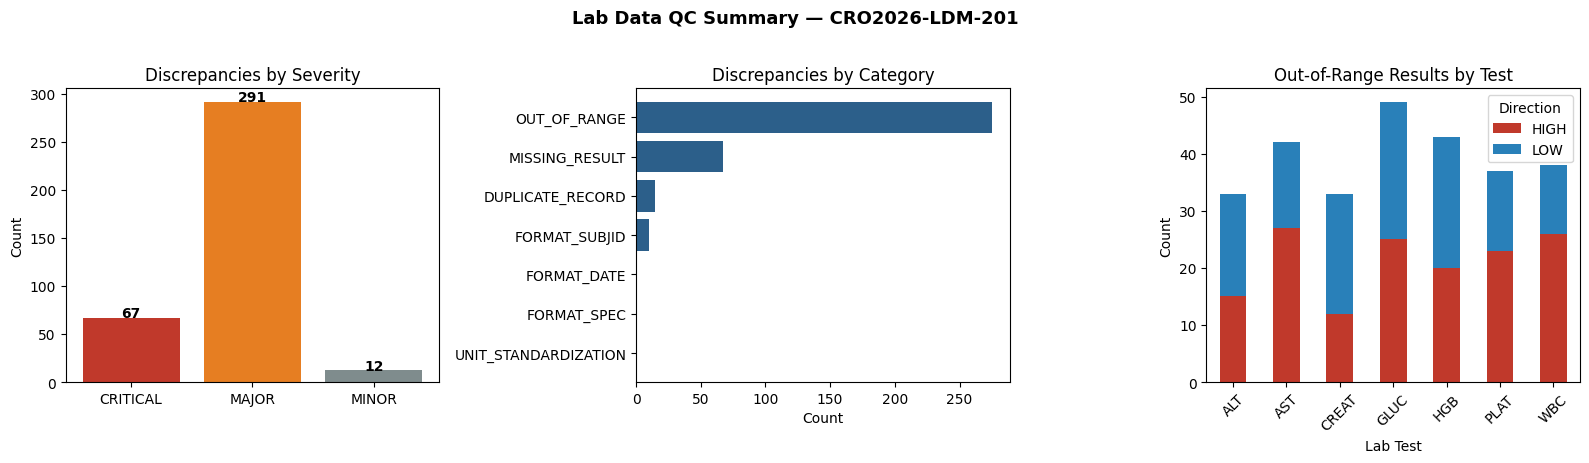

Chart saved: qc_summary_charts.png


In [24]:
# QC Summary Charts (Visuals)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("Lab Data QC Summary — CRO2026-LDM-201", fontsize=13, fontweight="bold", y=1.02)

# Chart 1: Discrepancies by severity
severity_order  = ["CRITICAL", "MAJOR", "MINOR"]
severity_counts = disc_df["SEVERITY"].value_counts().reindex(severity_order).fillna(0)
sev_colors      = ["#c0392b", "#e67e22", "#7f8c8d"]
axes[0].bar(severity_counts.index, severity_counts.values, color=sev_colors)
axes[0].set_title("Discrepancies by Severity")
axes[0].set_ylabel("Count")
for i, v in enumerate(severity_counts.values):
    axes[0].text(i, v + 1, str(int(v)), ha="center", fontsize=10, fontweight="bold")

# Chart 2: Discrepancies by category
cat_counts = disc_df["CATEGORY"].value_counts()
axes[1].barh(cat_counts.index[::-1], cat_counts.values[::-1], color="#2c5f8a")
axes[1].set_title("Discrepancies by Category")
axes[1].set_xlabel("Count")

# Chart 3: Out-of-range results by test
oor_by_test = (
    out_of_range.groupby(["LBTESTCD", "RANGE_FLAG"])
    .size()
    .unstack(fill_value=0)
)
oor_by_test.plot(
    kind="bar", stacked=True, ax=axes[2],
    color={"HIGH": "#c0392b", "LOW": "#2980b9"}
)
axes[2].set_title("Out-of-Range Results by Test")
axes[2].set_xlabel("Lab Test")
axes[2].set_ylabel("Count")
axes[2].legend(title="Direction", loc="upper right")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("qc_summary_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: qc_summary_charts.png")

# **8.0 Export Deliverables**

Three outputs are produced at the end of each QC cycle:

| File | Purpose |
|---|---|
| `cleaned_lab_data.csv` | Standardized dataset with QC flags; ready for SDTM mapping or safety review |
| `discrepancy_log.csv` | Auditable finding log with stub query text per discrepancy |
| `qc_summary_charts.png` | Visual summary for status updates and client reporting |

> The original raw file is preserved unmodified as the source record per document retention policy (see Transmission_Evidence_Log.md).

In [25]:
# Export All Deliverables
cleaned_full.to_csv("cleaned_lab_data.csv", index=False)
disc_df.to_csv("discrepancy_log.csv", index=False)

print("Exported successfully:")
print(f"  cleaned_lab_data.csv   — {len(cleaned_full)} rows, {len(cleaned_full.columns)} columns")
print(f"  discrepancy_log.csv    — {len(disc_df)} findings")
print(f"  qc_summary_charts.png  — saved above")
print()
print("=" * 60)
print("QC CYCLE COMPLETE")
print("=" * 60)
print(f"Records received:        {len(raw)}")
print(f"Records standardized:    {len(cleaned_full)}")
print(f"Total findings:          {len(disc_df)}")
critical = len(disc_df[disc_df["SEVERITY"] == "CRITICAL"])
major    = len(disc_df[disc_df["SEVERITY"] == "MAJOR"])
minor    = len(disc_df[disc_df["SEVERITY"] == "MINOR"])
print(f"  CRITICAL (block tx):   {critical}")
print(f"  MAJOR (query):         {major}")
print(f"  MINOR (auto-fixed):    {minor}")
print(f"\nFindings requiring active follow-up: {critical + major}")

Exported successfully:
  cleaned_lab_data.csv   — 1752 rows, 17 columns
  discrepancy_log.csv    — 370 findings
  qc_summary_charts.png  — saved above

QC CYCLE COMPLETE
Records received:        1752
Records standardized:    1752
Total findings:          370
  CRITICAL (block tx):   67
  MAJOR (query):         291
  MINOR (auto-fixed):    12

Findings requiring active follow-up: 358


# Next Steps in the LDM Workflow

This notebook covers **data receipt through QC**. In a live study, these outputs feed into:

**Query management**
Each `QUERY_TEXT` in the discrepancy log is routed to the relevant site or central lab via the EDC/query tracking system, with a resolution due date per the data transmission agreement.

**Client communication**
CRITICAL and MAJOR findings are summarized in a non-technical status update for the sponsor (see companion document: `Client_QC_Summary.md`).

**Audit trail filing**
The discrepancy log, cleaned dataset, and original raw file are filed per company document retention policy (see `Transmission_Evidence_Log.md`).

**Downstream SDTM mapping**
SDTM `LB` domain derivation (variable renaming, controlled terminology alignment, define.xml) is a separate downstream step, handled by a SDTM programmer after QC sign-off.
